Random Forest – Credit Card Fraud Detection

1.Load dataset and check fraud vs non-fraud counts to understand imbalance.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display first few rows
df.head()
# Count of fraud (1) and non-fraud (0)
fraud_counts = df['Class'].value_counts()
fraud_counts
# Percentage distribution
fraud_counts / len(df) * 100


Class
0    99.827251
1     0.172749
Name: count, dtype: float64

2.Separate features and target column and remove non-useful identifiers.

In [2]:
# Target variable
y = df['Class']

# Features (drop target column)
X = df.drop(columns=['Class'])

# Check shape
X.shape, y.shape


((284807, 30), (284807,))

3.Split dataset using stratified sampling so fraud ratio stays similar in train and test.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Verify fraud ratio
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


(Class
 0    0.998275
 1    0.001725
 Name: proportion, dtype: float64,
 Class
 0    0.998268
 1    0.001732
 Name: proportion, dtype: float64)

4.Train a baseline model like Logistic Regression for comparison.

In [10]:
log_reg = LogisticRegression(
    solver="saga",
    max_iter=600,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

log_reg.fit(X_train, y_train)


print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.11       148

    accuracy                           0.97     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.97      0.99     85443



C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


5.Train Random Forest model with parameters like n_estimators=100.

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.70      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443



6.Predict and evaluate using precision, recall, F1-score instead of accuracy.

In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results


,Model,Precision,Recall,F1-Score
0,Logistic Regression,0.057471,0.878378,0.107884
1,Random Forest,0.971963,0.702703,0.815686


7.Plot feature importances to identify key fraud indicators.

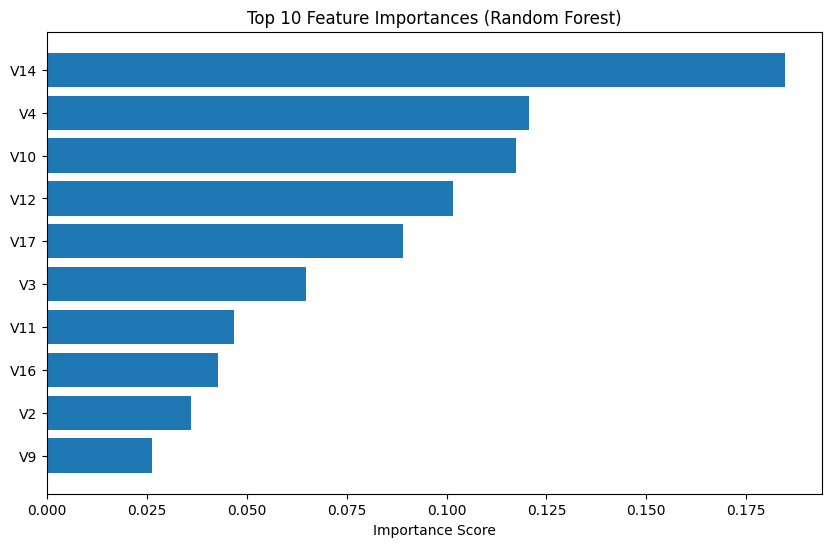

In [13]:
importances = rf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()


8.Compare Random Forest performance against baseline model.

In [15]:
# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison_df


,Model,Precision,Recall,F1-Score
0,Logistic Regression (Baseline),0.057471,0.878378,0.107884
1,Random Forest,0.971963,0.702703,0.815686


9.Save best model using joblib for reuse.

In [14]:
joblib.dump(rf, "random_forest_fraud_model.pkl")


['random_forest_fraud_model.pkl']